In [1]:
import pandas as pd
import mysql.connector

# connect
conn = mysql.connector.connect(
    host="zburnside.mysql.pythonanywhere-services.com",
    user="zburnside",
    password="Bearsocks24!",
    database="zburnside$golfnow"
)

# load into DataFrame
df = pd.read_sql("SELECT * FROM tractor_supply_days", conn)

conn.close()

df

/tmp/ipykernel_26/3237872598.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM tractor_supply_days", conn)


,product_id,category,code,message,days,collection_date
0,124145499,,,,0,2025-06-24
1,124145499,,,,0,2025-06-25
2,124145499,,,,0,2025-06-26
3,124145499,,,,0,2025-07-05
4,124145499,,,,0,2025-07-06
...,...,...,...,...,...,...
2446,187448499,,,,0,2025-08-15
2447,187448499,,,,0,2025-08-16
2448,187448499,,,,0,2025-08-17
2449,187448499,,,,0,2025-08-18


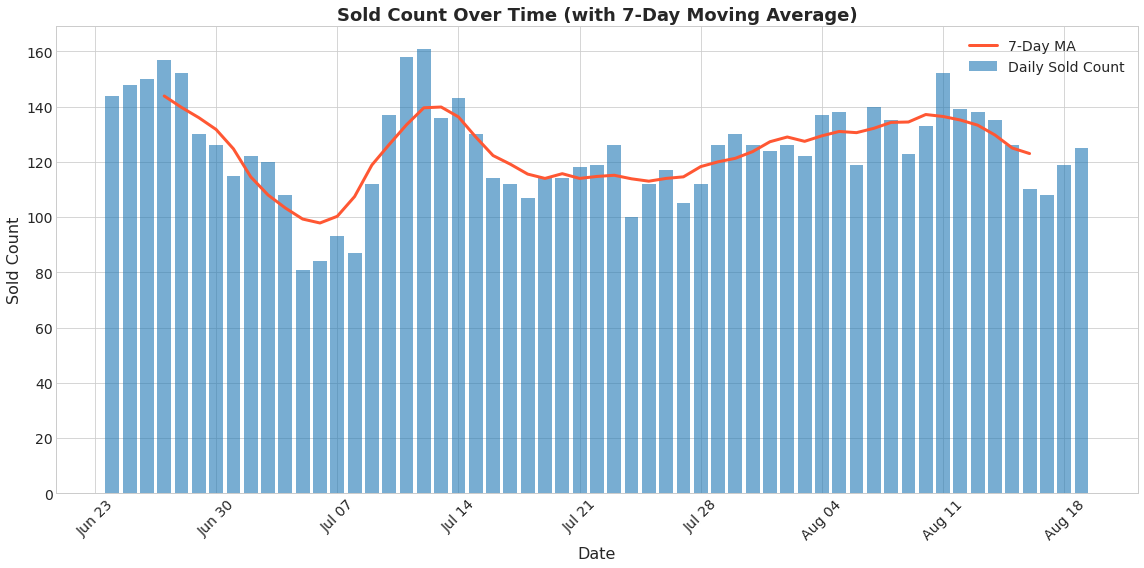

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Extract sold counts
df['sold_count'] = (
    df['message']
      .str.extract(r'(\d+)\s*(?:sold|times)', expand=False)
      .fillna(0)
      .astype(int)
)

# Parse dates and aggregate
df['collection_date'] = pd.to_datetime(df['collection_date'])
daily = df.groupby(df['collection_date'].dt.to_period('D'))['sold_count'] \
          .sum() \
          .to_timestamp() \
          .sort_index()

# 7‑day rolling average
rolling = daily.rolling(window=7, center=True).mean()

# Plot with larger figure
plt.style.use('seaborn-whitegrid')
fig, ax = plt.subplots(figsize=(16,8))

# Bars and rolling line
ax.bar(daily.index, daily.values, width=0.8, alpha=0.6, label='Daily Sold Count')
ax.plot(rolling.index, rolling.values, color='#FF5733', linewidth=3, label='7‑Day MA')

# Highlight peak day with label above
peak_date = daily.idxmax()
peak_val  = daily.max()
offset = max(daily) * 0.05

# Date formatting
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))
ax.tick_params(axis='x', rotation=45, labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# Labels & legend with larger fonts
ax.set_title('Sold Count Over Time (with 7‑Day Moving Average)', fontsize=18, weight='bold')
ax.set_xlabel('Date', fontsize=16)
ax.set_ylabel('Sold Count', fontsize=16)
ax.legend(fontsize=14)

plt.tight_layout()
plt.show()


In [3]:
import pandas as pd
import mysql.connector

# connect
conn = mysql.connector.connect(
    host="zburnside.mysql.pythonanywhere-services.com",
    user="zburnside",
    password="Bearsocks24!",
    database="zburnside$golfnow"
)

# load into DataFrame
df = pd.read_sql(
    "SELECT * FROM ecwid_products",
    conn,
)

conn.close()

df

/tmp/ipykernel_26/400167569.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


,id,sku,inStock,name,price,priceInProductList,defaultDisplayedPrice,defaultDisplayedPriceFormatted,url,autogeneratedSlug,created,updated,warningLimit,categoryIds,volume,googleProductCategoryName,maxPurchaseQuantity,favoritesCount,wholesalePrices
0,156357519,MRK,1,Marek's Vaccination Service,3.00,3.00,3.00,$3.00,https://meyerhatchery.com/products/mareks-vacc...,mareks-vaccination-service,2019,2025,10,50930083,0.0,Animals & Pet Supplies > Live Animals,NaN,11,"[{""price"": 1.5, ""quantity"": 2}, {""price"": 1, ""..."
1,178014156,VPWO,1,"Vital Pack 4-oz, Non-Meat Birds - Ships with C...",5.25,5.25,5.25,$5.25,https://meyerhatchery.com/products/vital-pack-...,vital-pack-4-oz-non-meat-birds-ships-with-chic...,2020,2025,0,50930083,0.0,Animals & Pet Supplies > Live Animals,1.0,6,{}
2,178014208,NPIP,1,NPIP Certificate,0.00,0.00,0.00,$0.00,https://meyerhatchery.com/products/npip-certif...,npip-certificate,2020,2025,0,50930083,0.0,Animals & Pet Supplies,NaN,0,{}
3,178014264,BMWO,1,"Vital Pack Plus 4-oz, Meat Birds - Ships with ...",5.25,5.25,5.25,$5.25,https://meyerhatchery.com/products/vital-pack-...,vital-pack-plus-4-oz-meat-birds-ships-with-chi...,2020,2025,0,50930083,0.0,Animals & Pet Supplies > Live Animals,1.0,0,{}
4,178014281,MMMF,1,Meal Maker Day Old Chick,0.00,0.00,0.00,$0.00,https://meyerhatchery.com/products/meal-maker-...,meal-maker-day-old-chick,2020,2024,0,50930083,0.0,Animals & Pet Supplies > Live Animals,1.0,25,{}
5,178014350,MRKW,1,Marek's Vaccination Service,3.00,3.00,3.00,$3.00,https://meyerhatchery.com/products/mareks-vacc...,mareks-vaccination-service-1,2020,2025,0,50930083,0.0,Animals & Pet Supplies,NaN,6,"[{""price"": 1.5, ""quantity"": 2}, {""price"": 1, ""..."
6,252468814,MRKF,1,Marek's Vaccination Service,3.00,3.00,3.00,$3.00,https://meyerhatchery.com/products/mareks-vacc...,mareks-vaccination-service-2,2020,2025,0,50930083,0.0,Animals & Pet Supplies,NaN,2,"[{""price"": 1.5, ""quantity"": 2}, {""price"": 1, ""..."
7,283120004,COCCI,1,Coccidiosis Spray,0.25,0.25,0.25,$0.25,https://meyerhatchery.com/products/coccidiosis...,coccidiosis-spray,2021,2023,0,50930083,0.0,Animals & Pet Supplies > Live Animals,NaN,2,{}
8,505219234,MRKH,1,Marek's Vaccination Service,4.00,4.00,4.00,$4.00,https://meyerhatchery.com/products/mareks-vacc...,mareks-vaccination-service-3,2022,2025,1,50930083,0.0,Animals & Pet Supplies,NaN,1,"[{""price"": 1.5, ""quantity"": 2}, {""price"": 1, ""..."
9,522446499,VPPM,1,"Vital Pack Plus 4-oz, Meat Birds - Ships with ...",5.25,5.25,5.25,$5.25,https://meyerhatchery.com/products/vital-pack-...,vital-pack-plus-4-oz-meat-birds-ships-with-wat...,2023,2024,1,50930083,0.0,Animals & Pet Supplies,NaN,0,{}


In [3]:
import requests
import pandas as pd
import io

def fetch_flock_data():
    try:
        url = (
            "https://publicdashboards.dl.usda.gov/t/MRP_PUB/views/"
            "VS_Avian_HPAIConfirmedDetections2022/"
            "HPAI2022ConfirmedDetections.csv"
            "?%3Aformat=crosstab&%3Asheet=List%20of%20Detections%20by%20Day"
        )
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.text

        # Read into DataFrame
        df = pd.read_csv(
            io.StringIO(data),
            parse_dates=["Confirmed", "Control Area Released"],
            thousands=","
        )

        # Rename and convert the 'Confirmed' column to a proper datetime field
        df = df.rename(columns={"Confirmed": "Outbreak Date"})
        df["Outbreak Date"] = pd.to_datetime(df["Outbreak Date"], errors="coerce")

        # —— NEW: Rename & cast Birds Affected → Flock Size ——
        df = df.rename(columns={"Birds Affected": "Flock Size"})
        df["Flock Size"] = (
            df["Flock Size"]
              .astype(str)
              .str.replace(",", "")
              .astype(int)
        )
        # —— END NEW ——

        # State name → abbreviation map
        state_abbrev = {
            'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
            'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
            'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
            'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
            'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
            'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN',
            'Mississippi': 'MS', 'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE',
            'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
            'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC',
            'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR',
            'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
            'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
            'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
            'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
        }

        # Map full state names to abbreviations
        df["State Abbreviation"] = df["State"].map(state_abbrev)

        return df

    except Exception as e:
        print(f"Error fetching flock data: {e}")
        return pd.DataFrame()

In [4]:
df = fetch_flock_data()

/tmp/ipykernel_4/877439477.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
/tmp/ipykernel_4/877439477.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


In [5]:
df

,Outbreak Date,Control Area Released,County Name,Measure Names,Production,Special Id,State,Flock Size,State Abbreviation
0,2025-12-05,NaN,Galveston,Birds Affected,Animal Rescue / Rehabilitation,Galveston 01,Texas,20,TX
1,2024-04-12,20-Jun-24,Roosevelt,Birds Affected,Commercial Breeder (Multiple Bird Species),Roosevelt 01,New Mexico,61500,NM
2,2024-04-17,26-Jul-24,Roosevelt,Birds Affected,Commercial Breeder (Multiple Bird Species),Roosevelt 03,New Mexico,51800,NM
3,2024-04-15,29-May-24,Roosevelt,Birds Affected,Commercial Breeder (Multiple Bird Species),Roosevelt 02,New Mexico,15900,NM
4,2023-11-06,30-Nov-23,Hamilton,Birds Affected,Commercial Breeder (Multiple Bird Species),Hamilton 03,Iowa,15000,IA
...,...,...,...,...,...,...,...,...,...
1935,2025-11-07,Active,Lagrange,Birds Affected,WOAH Poultry,LaGrange 14,Indiana,18300,IN
1936,2025-11-05,Active,Lagrange,Birds Affected,WOAH Poultry,LaGrange 09,Indiana,19900,IN
1937,2025-12-08,Active,Stutsman,Birds Affected,WOAH Poultry,Stutsman 04,North Dakota,480,ND
1938,2025-12-05,Active,Orleans,Birds Affected,WOAH Poultry,Orleans 02,Vermont,290,VT


In [6]:
import pandas as pd

def fetch_hpai_wild_birds():
    url = "https://www.aphis.usda.gov/sites/default/files/hpai-wild-birds.csv"
    try:
        df = pd.read_csv(url)
        print(f"Wild birds dataset loaded: {len(df)} rows, {len(df.columns)} columns")
        return df
    except Exception as e:
        print(f"Error fetching wild bird data: {e}")
        return pd.DataFrame()

# Example use
wild_birds_df = fetch_hpai_wild_birds()
wild_birds_df.columns

Wild birds dataset loaded: 16651 rows, 9 columns


Index(['State', 'County', 'Collection Date', 'Date Detected', 'HPAI Strain',
       'Bird Species', 'WOAH Classification', 'Sampling Method',
       'Submitting Agency'],
      dtype='object')

In [7]:
import pandas as pd

def fetch_hpai_mammals():
    url = "https://www.aphis.usda.gov/sites/default/files/hpai-mammals.csv"
    try:
        df = pd.read_csv(url)
        print(f"Mammals dataset loaded: {len(df)} rows, {len(df.columns)} columns")
        return df
    except Exception as e:
        print(f"Error fetching mammal data: {e}")
        return pd.DataFrame()

# Example use
mammals_df = fetch_hpai_mammals()
mammals_df.columns

Mammals dataset loaded: 674 rows, 6 columns


Index(['State', 'County', 'Date Collected', 'Date Detected', 'HPAI Strain',
       'Species'],
      dtype='object')

In [4]:
import requests
import pandas as pd
from io import StringIO

# Your function
def fetch_data(start_date, end_date):
    url = (
        f"https://europe-west1-fao-empresi.cloudfunctions.net/getLatestEventsByDate"
        f"?animal_type=all&diagnosis_status=confirmed&disease=avian_influenza"
        f"&start_date={start_date}&end_date={end_date}"
    )
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        csv_text = response.content.decode('utf-8')
        df = pd.read_csv(StringIO(csv_text))
        return df
    except Exception as e:
        print(f"ERROR fetching data: {e}")
        return pd.DataFrame()

# Tes5
df_2020 = fetch_data("2019-01-01", "2025-12-17")
print("Rows:", len(df_2020))
print("Columns:", df_2020.columns.tolist())
df_2020

Rows: 15000
Columns: ['id_event', 'disease', 'serotype', 'latitude', 'longitude', 'locality', 'country', 'region', 'observation_date', 'report_date', 'species', 'diagnosis_source', 'humans_affected', 'humans_deaths', 'diagnosis_status']


,id_event,disease,serotype,latitude,longitude,locality,country,region,observation_date,report_date,species,diagnosis_source,humans_affected,humans_deaths,diagnosis_status
0,423860,Influenza - Avian,;H5N1 HPAI;,52.679748,18.107115,174909STRZELCE,Poland,Europe,2025-12-05T00:00:00Z,2025-12-17T00:00:00Z,"Wild,Eurasian buzzard (common buzzard):Buteo b...",WOAH (former OIE),NaN,NaN,Confirmed
1,423857,Influenza - Avian,;H5N1 HPAI;,59.927500,10.755620,174930OSLO,Norway,Europe,2025-12-09T00:00:00Z,2025-12-17T00:00:00Z,"Wild,Herring Gull:Larus argentatus(Laridae),",WOAH (former OIE),NaN,NaN,Confirmed
2,423859,Influenza - Avian,;H5N1 HPAI;,52.964182,19.761914,174916LUTOCIN,Poland,Europe,2025-12-15T00:00:00Z,2025-12-17T00:00:00Z,"Domestic,Unspecified bird,",WOAH (former OIE),NaN,NaN,Confirmed
3,423861,Influenza - Avian,;H5N1 HPAI;,52.803746,18.271382,174908INOWROC AW,Poland,Europe,2025-11-22T00:00:00Z,2025-12-17T00:00:00Z,"Wild,Rook,",WOAH (former OIE),NaN,NaN,Confirmed
4,423858,Influenza - Avian,;H5N1 HPAI;,51.801387,18.728395,174923P CZNIEW,Poland,Europe,2025-12-15T00:00:00Z,2025-12-17T00:00:00Z,"Wild,Bean goose (Anser fabalis),",WOAH (former OIE),NaN,NaN,Confirmed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,344899,Influenza - Avian,;H5N1 HPAI;,39.723660,-121.579380,Butte,United States of America,Americas,2022-12-27T00:00:00Z,2023-01-24T00:00:00Z,"Wild,Bobcat (Lynx rufus),",National authorities,NaN,NaN,Confirmed
14996,342172,Influenza - Avian,;H5N1 HPAI;,51.654649,18.919070,WojsÅ‚awice,Poland,Europe,2022-12-27T00:00:00Z,2023-01-24T00:00:00Z,"Domestic,Unspecified bird,",WOAH (former OIE),NaN,NaN,Confirmed
14997,342156,Influenza - Avian,;H5N1 HPAI;,51.744709,18.351701,Oszczeklin,Poland,Europe,2023-01-11T00:00:00Z,2023-01-24T00:00:00Z,"Domestic,Unspecified bird,",WOAH (former OIE),NaN,NaN,Confirmed
14998,342190,Influenza - Avian,;H5N1 HPAI;,49.924643,19.196440,Bielany,Poland,Europe,2023-01-16T00:00:00Z,2023-01-24T00:00:00Z,"Wild,Mute Swan:Cygnus olor(Anatidae),",WOAH (former OIE),NaN,NaN,Confirmed


In [1]:
df_2020

NameError: name 'df_2020' is not defined